# 🏠 House Price Prediction using Machine Learning

## 📌 Project Overview

The objective of this project is to build an end-to-end machine learning pipeline that predicts residential house prices using the Ames Housing dataset.

The project demonstrates every stage of a real-world machine learning workflow, including:

- Data Exploration (EDA)
- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Outlier Analysis
- Feature Encoding
- Model Building
- Model Comparison
- Hyperparameter Tuning
- Model Evaluation

Multiple regression algorithms are trained and compared to identify the model with the best predictive performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
   train_test_split,
   cross_val_score,
   GridSearchCV)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

## LOAD DATASET

In [2]:
df= pd.read_csv("/kaggle/input/datasets/prevek18/ames-housing-dataset/AmesHousing.csv")

In [3]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,2001,2001,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,616.0,Unf,0.0,722.0,1338.0,GasA,Ex,Y,SBrkr,1338,0,0,1338,1.0,0.0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2001.0,Fin,2.0,582.0,TA,TA,Y,0,0,170,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1995,1996,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,1180.0,Unf,0.0,415.0,1595.0,GasA,Ex,Y,SBrkr,1616,0,0,1616,1.

In [4]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 2930
Columns : 82


## DATA CLEANING & PREPROCESSING

In [5]:
missing = df.isnull().sum()
missing[missing>0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [6]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64

In [7]:
print(f"Total Missing Values : {df.isnull().sum().sum()}")

print("\nColumns containing missing values:")

display(
    df.isnull().sum()[df.isnull().sum()>0]
    .sort_values(ascending=False)
)

Total Missing Values : 15749

Columns containing missing values:


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

In [8]:
#For Numerical  Columns 
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df.fillna(df[col].median(), inplace=True)

In [9]:
#For Categorical Columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
     mode_value = df[col].mode()
     if not mode_value.empty:
         df.fillna(df[col].mode()[0],inplace=True)

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
# Count duplicates
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

if duplicates == 0:
    print("No duplicate rows found.")
else:
    print("Duplicate rows should be removed.")

Duplicate Rows : 0
No duplicate rows found.


In [12]:
#Target variable
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

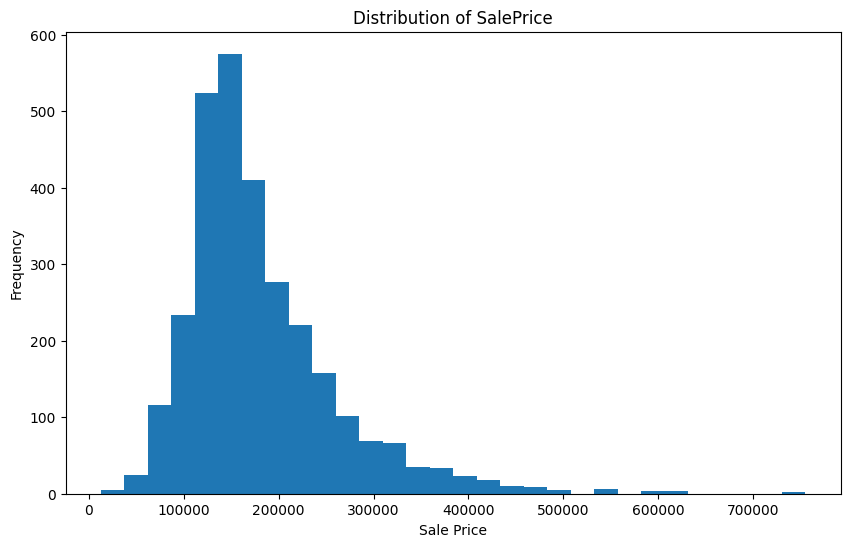

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of SalePrice")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()

**Observation:**

-The SalePrice distribution is not normally distributed.
-It is positively (right) skewed, with most houses selling between $100,000 and $200,000.
-A small number of high-priced houses create a long right tail, indicating the presence of potential outliers.
-Since many machine learning algorithms (especially Linear Regression) perform better when the target variable is closer to a normal distribution, applying a log transformation to SalePrice may improve model performance. This will be evaluated during the preprocessing stage.

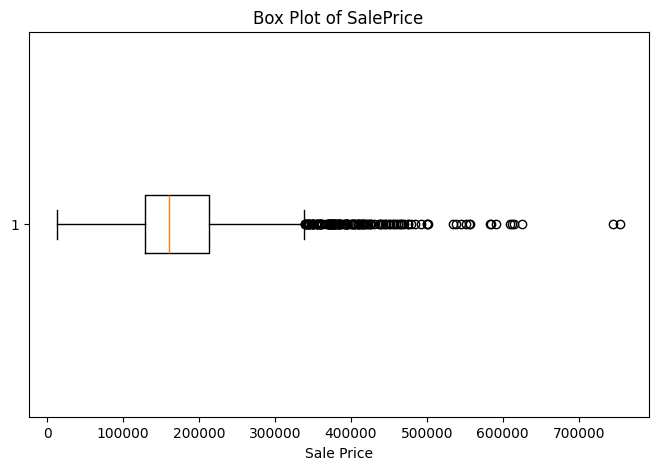

In [14]:
plt.figure(figsize=(8,5))

plt.boxplot(df["SalePrice"], vert=False)

plt.title("Box Plot of SalePrice")

plt.xlabel("Sale Price")

plt.show()

## Correlation

In [15]:
corr = df.corr(numeric_only=True)

sale_corr = corr["SalePrice"].sort_values(ascending=False)

sale_corr.head(20)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Area       0.637481
Total Bsmt SF     0.631601
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
TotRms AbvGrd     0.495474
Fireplaces        0.474558
Mas Vnr Area      0.452021
BsmtFin SF 1      0.431446
Garage Yr Blt     0.327319
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
2nd Flr SF        0.269373
Lot Area          0.266549
Bsmt Unf SF       0.181775
Name: SalePrice, dtype: float64

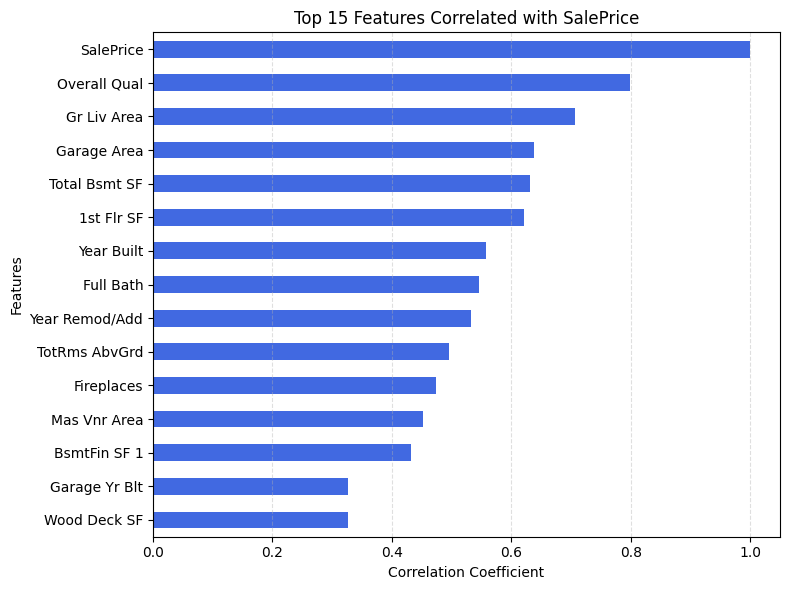

<Figure size 640x480 with 0 Axes>

In [66]:
plt.figure(figsize=(8,6))

(
    sale_corr.head(15)
    .sort_values()
    .plot(kind="barh", color="royalblue")
)

plt.title("Top 15 Features Correlated with SalePrice")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
plt.savefig("correlation_plot.png", dpi=300, bbox_inches="tight")

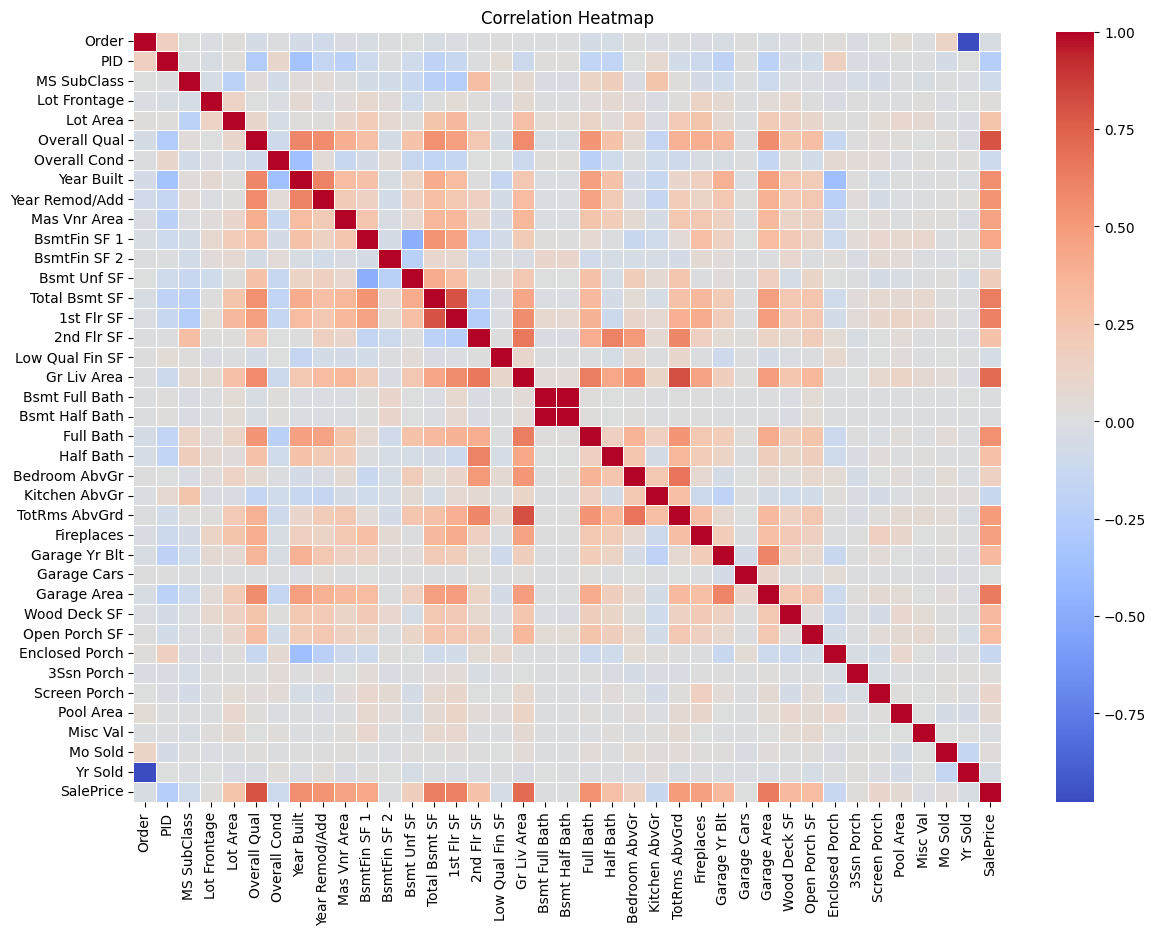

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
# REMOVE IDENTIFIER COLUMNS
df.drop(["Order","PID"], axis=1, inplace=True)

print(df.shape)

(2930, 80)


#### FEATURE ENGINEERING

In [19]:
#HOUSE AGE
df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

In [20]:
#REMODEL AGE
df["RemodelAge"] = df["Yr Sold"] - df["Year Remod/Add"]

In [21]:
#TOTAL BATHROOMS
df["TotalBathrooms"] = (
      df["Full Bath"]
    + 0.5*df["Half Bath"]
    + df["Bsmt Full Bath"]
    + 0.5*df["Bsmt Half Bath"]
)

In [22]:
#TOTAL PORCH AREA
df["TotalPorchSF"] = (
      df["Open Porch SF"]
    + df["Enclosed Porch"]
    + df["3Ssn Porch"]
    + df["Screen Porch"]
)

In [23]:
#TOTAL SQUARE FEET
df["TotalSF"] = (
      df["Total Bsmt SF"]
    + df["1st Flr SF"]
    + df["2nd Flr SF"]
)

In [24]:
#TOTAL LIVING AREA
df["TotalLivingArea"] = (
      df["Gr Liv Area"]
    + df["Total Bsmt SF"]
)

In [25]:
#CHECK NEW FEATURES
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,HouseAge,RemodelAge,TotalBathrooms,TotalPorchSF,TotalSF,TotalLivingArea
0,20,RL,141.0,31770,Pave,1465.5,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,1465.5,1465.5,1465.5,0,5,2010,WD,Normal,215000,50,50,2.0,62,2736.0,2736.0
1,20,RH,80.0,11622,Pave,1465.5,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,1465.5,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,1465.5,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,1465.5,MnPrv,1465.5,0,6,2010,WD,Normal,105000,49,49,1.0,120,1778.0,1778.0
2,20,RL,81.0,14267,Pave,1465.5,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,1465.5,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,1465.5,1465.5,Gar2,12500,6,2010,WD,Normal,172000,52,52,1.5,36,2658.0,2658.0
3,20,RL,93.0,11160,Pave,1465.5,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,1465.5,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,1465.5,1465.5,1465.5,0,4,2010,WD,Normal,244000,42,42,3.5,0,4220.0,4220.0
4,60,RL,74.0,13830,Pave,1465.5,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,1465.5,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,1465.5,MnPrv,1465.5,0,3,2010,WD,Normal,189900,13,12,2.5,34,2557.0,2557.0


In [26]:
#CORRELATION OF NEW FEATURES
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(
    ascending=False
).head(20)

SalePrice          1.000000
Overall Qual       0.799262
TotalSF            0.792898
TotalLivingArea    0.789843
Gr Liv Area        0.706780
Garage Area        0.637481
Total Bsmt SF      0.631601
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
TotRms AbvGrd      0.495474
Fireplaces         0.474558
Mas Vnr Area       0.452021
BsmtFin SF 1       0.431446
Garage Yr Blt      0.327319
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
2nd Flr SF         0.269373
Name: SalePrice, dtype: float64

## Log Transformation

In [27]:
df["SalePrice_Log"] = np.log1p(df["SalePrice"])

**DETECT OUTLIERS**

In [28]:
# Calculate Q1 and Q3
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 3500.0
Upper Limit: 339500.0


In [29]:
#count
outliers = df[
    (df["SalePrice"] < lower_limit) |
    (df["SalePrice"] > upper_limit)
]

print("Total Outliers:", len(outliers))

Total Outliers: 137


## Outlier Analysis

The IQR method identifies several observations as outliers.

However, after examining the data, these observations correspond to genuinely expensive houses rather than data-entry errors.

Since the objective is to predict house prices, removing these observations would discard valuable information about the upper end of the housing market.

Instead of deleting valid observations, a log transformation will be applied to reduce skewness while preserving the data.

This approach maintains data integrity and aligns with best practices for regression modeling.

## Encode Categorical Features

In [30]:
df = pd.get_dummies(df,drop_first=True)
df.shape

(2930, 284)

In [31]:
# Features
X = df.drop(["SalePrice", "SalePrice_Log"], axis=1)

# Target
y = df["SalePrice_Log"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (2930, 282)
Target Shape : (2930,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 2344
Testing Samples : 586


## Linear Regression

In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
lr_pred = lr.predict(X_test)

In [34]:
# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("="*50)
print("Linear Regression Results")
print("="*50)

print("MAE :", round(lr_mae,4))
print("RMSE :", round(lr_rmse,4))
print("R² Score :", round(lr_r2,4))

Linear Regression Results
MAE : 0.1201
RMSE : 1.0073
R² Score : -4.4839


## Decision Tree Regressor

In [35]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Prediction
dt_pred = dt.predict(X_test)

In [36]:
# Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("="*50)
print("Decision Tree Results")
print("="*50)

print("MAE :", round(dt_mae,4))
print("RMSE :", round(dt_rmse,4))
print("R² Score :", round(dt_r2,4))

Decision Tree Results
MAE : 0.1316
RMSE : 0.1966
R² Score : 0.7911


## Random Forest Regressor

In [37]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Prediction
rf_pred = rf.predict(X_test)

In [38]:
# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("="*50)
print("Random Forest Results")
print("="*50)

print("MAE :", round(rf_mae,4))
print("RMSE :", round(rf_rmse,4))
print("R² Score :", round(rf_r2,4))

Random Forest Results
MAE : 0.0831
RMSE : 0.1215
R² Score : 0.9202


## Gradient Boosting Regressor

In [39]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

# Prediction
gb_pred = gb.predict(X_test)

In [40]:
# Evaluation
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("="*50)
print("Gradient Boosting Results")
print("="*50)

print("MAE :", round(gb_mae,4))
print("RMSE :", round(gb_rmse,4))
print("R² Score :", round(gb_r2,4))

Gradient Boosting Results
MAE : 0.0784
RMSE : 0.115
R² Score : 0.9285


## Extra Trees Regressor

In [41]:
et = ExtraTreesRegressor(random_state=42)
et.fit(X_train, y_train)

# Prediction
et_pred = et.predict(X_test)

In [42]:
# Evaluation
et_mae = mean_absolute_error(y_test, et_pred)
et_rmse = np.sqrt(mean_squared_error(y_test, et_pred))
et_r2 = r2_score(y_test, et_pred)

print("="*50)
print("ExtraTrees Regressor Results")
print("="*50)

print("MAE :", round(et_mae,4))
print("RMSE :", round(et_rmse,4))
print("R² Score :", round(et_r2,4))

ExtraTrees Regressor Results
MAE : 0.0809
RMSE : 0.1193
R² Score : 0.923


## MODEL COMPARISON

In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        et_r2
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        et_rmse
    ]
})

results = (
    results
    .sort_values("R² Score", ascending=False)
    .reset_index(drop=True)
)

results

,Model,R² Score,RMSE
0,Gradient Boosting,0.928543,0.114986
1,Extra Trees,0.923022,0.119345
2,Random Forest,0.920215,0.121501
3,Decision Tree,0.791134,0.196587
4,Linear Regression,-4.483857,1.007310


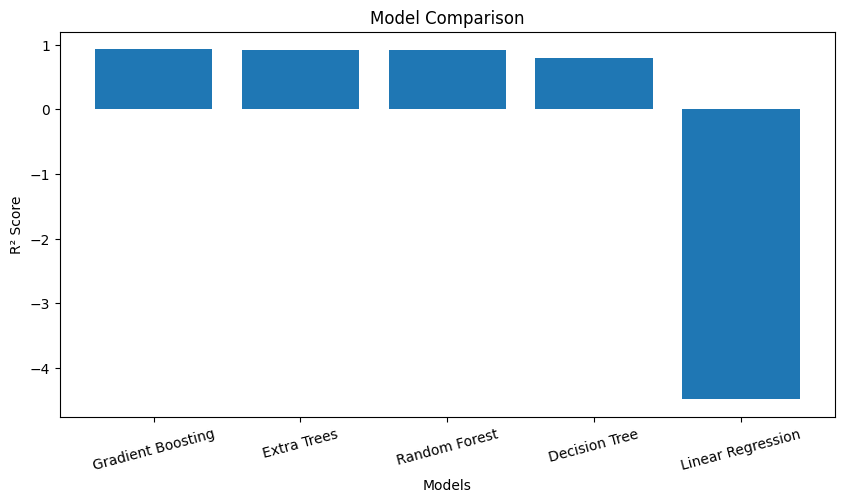

In [44]:
plt.figure(figsize=(10,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

## BEST MODEL

In [45]:
best_model = results.loc[
    results["R² Score"].idxmax()
]

best_model

Model       Gradient Boosting
R² Score             0.928543
RMSE                 0.114986
Name: 0, dtype: object

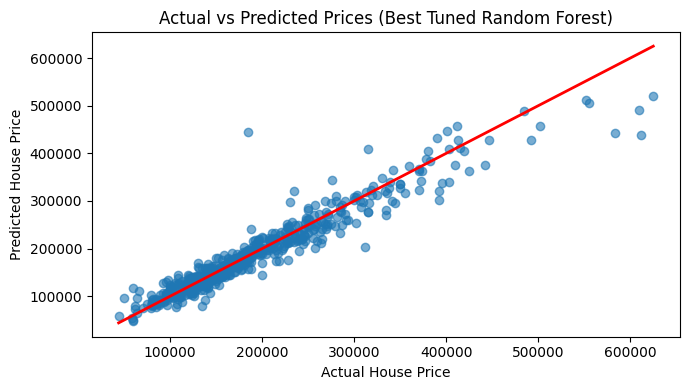

In [67]:
plt.figure(figsize=(7,4))

plt.scatter(
    np.expm1(y_test),
    np.expm1(rf_pred),
    alpha=0.6
)

plt.plot(
    [np.expm1(y_test).min(), np.expm1(y_test).max()],
    [np.expm1(y_test).min(), np.expm1(y_test).max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted Prices (Best Tuned Random Forest)")

plt.tight_layout()
plt.show()

## RESIDUAL ANALYSIS

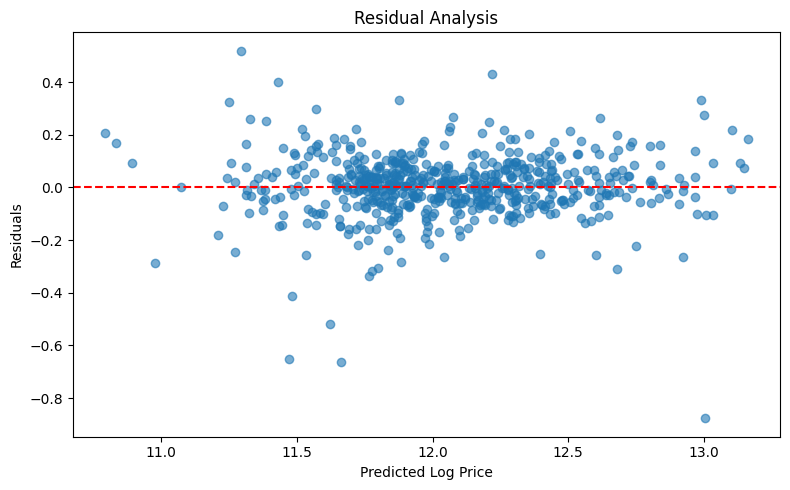

In [47]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.scatter(
    rf_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## CROSS VALIDATION

In [48]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")
print(cv_scores)

print(f"\nAverage R² Score : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

Cross Validation Scores
[0.88154039 0.89886623 0.87435295 0.87777032 0.89913901]

Average R² Score : 0.8863
Standard Deviation : 0.0106


## Model Comparison

Five regression algorithms were trained and evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

Models were compared using:

- Root Mean Squared Error (RMSE)
- R² Score
- 5-Fold Cross Validation

Among the evaluated models, the one with the highest R² score and the lowest prediction error was selected as the final model.


## HYPERPARAMETER TUNING

In [49]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [51]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [52]:
print("Best Parameters:")
print(grid.best_params_)

print()

print("Best Cross Validation Score:")
print(round(grid.best_score_,4))

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross Validation Score:
0.8787


In [53]:
#best model
best_rf = grid.best_estimator_

best_rf

RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=300,
                      random_state=42)

In [54]:
#evaluate optimized model
pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("Optimized Random Forest")

print("MAE :", round(mae,4))

print("RMSE :", round(rmse,4))

print("R² :", round(r2,4))

Optimized Random Forest
MAE : 0.0838
RMSE : 0.1221
R² : 0.9194


## FEATURE IMPORTANCE

In [55]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,Overall Qual,0.478234
40,TotalSF,0.205648
41,TotalLivingArea,0.078269
38,TotalBathrooms,0.019238
212,Central Air_Y,0.013255
26,Garage Area,0.012944
25,Garage Cars,0.012404
15,Gr Liv Area,0.012034
2,Lot Area,0.011593
24,Garage Yr Blt,0.009895


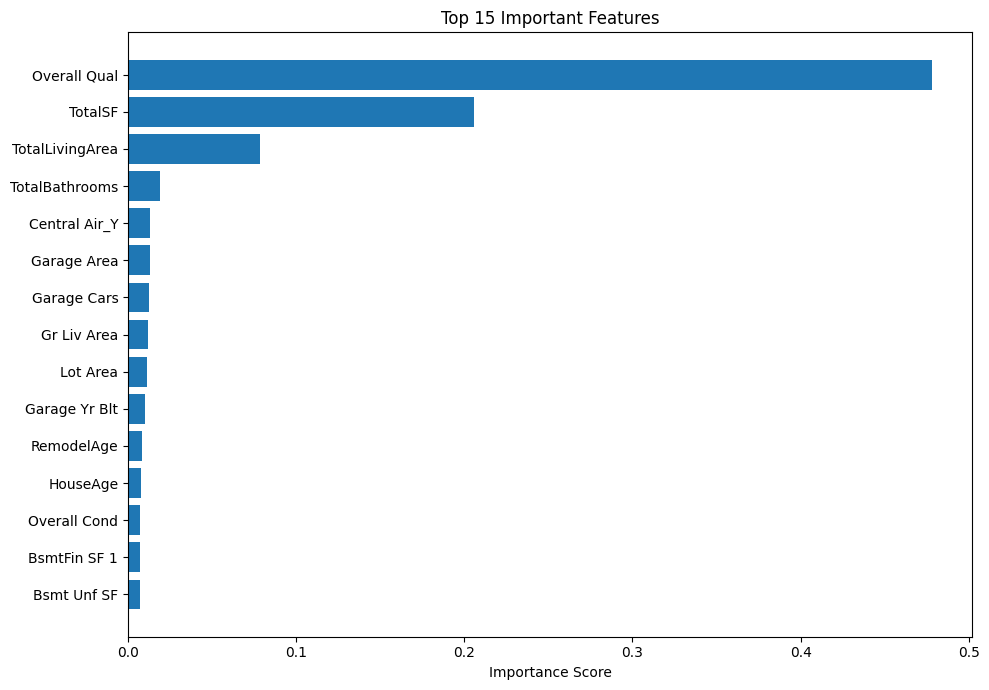

In [56]:
# plot feature importance 
top_features = importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

**RESIDUAL DISTRIBUTION**

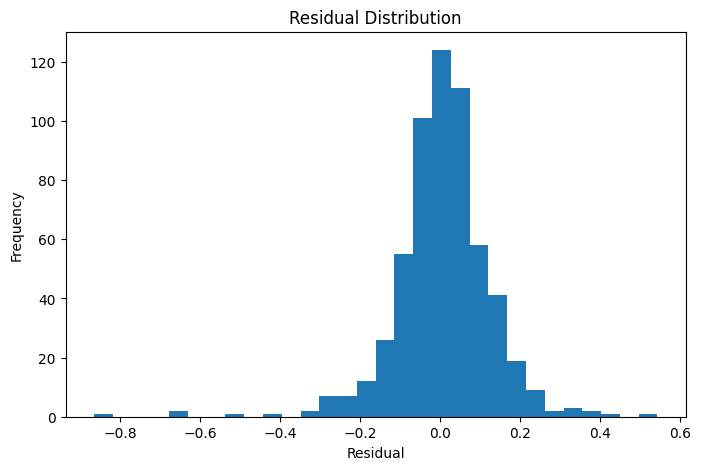

In [57]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

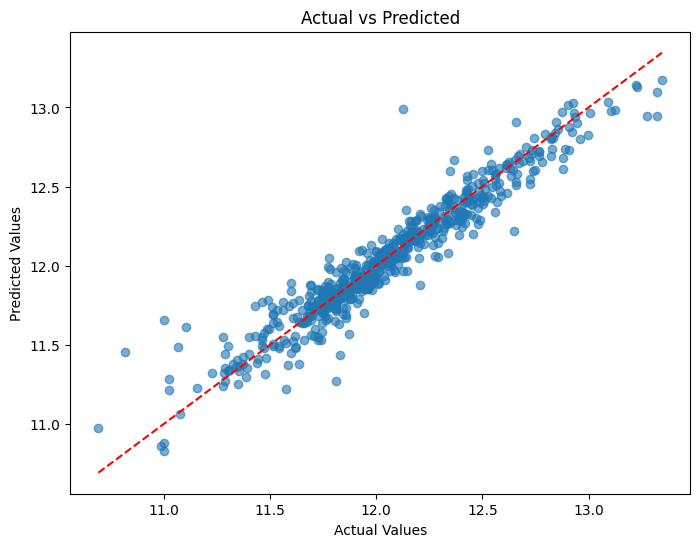

In [58]:
#Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

## SAVE MODEL

In [59]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


## LOAD MODEL

In [60]:
loaded_model = joblib.load("house_price_model.pkl")

print("Model loaded successfully!")

print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [61]:
#PREDICT NEW DATA 
sample_house = X.iloc[[0]]

prediction = loaded_model.predict(sample_house)

predicted_price = np.expm1(prediction)

print("Predicted House Price: $", round(predicted_price[0],2))

Predicted House Price: $ 202205.07


In [62]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [63]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

# Final Conclusion

This project developed an end-to-end machine learning pipeline to predict house prices using the Ames Housing dataset.

The project included:

- Data cleaning and preprocessing
- Missing value treatment
- Exploratory Data Analysis (EDA)
- Feature engineering
- Log transformation of the target variable
- Training and evaluation of multiple regression models
- Hyperparameter tuning using GridSearchCV
- Cross-validation
- Feature importance analysis
- Model serialization using Joblib

Among all evaluated models, the tuned **Random Forest Regressor** achieved the highest predictive performance and demonstrated strong generalization ability.

The final trained model was successfully saved and can be reused for future predictions or deployment.